# Analyse météorologique de la côte au large du CPE La Ramée

Le point d'intérêt se situe à la latitude 47.366445362339576 et à longitude -61.87199621249825.

In [19]:
from pathlib import Path

import plotly
import plotly.graph_objects as go
import polars as pl
from IPython.display import HTML, display

from src.analysis import (
    calculate_storm_return_periods,
    create_land_sea_diff_fig,
    create_storms_qq_plot,
    extract_storms,
    fit_storms,
    write_diff_return_periods,
    write_storm_return_periods,
)
from src.data import (
    combine_to_ice_cover,
    read_era5_data,
    read_fetch,
    read_weather_data,
)
from src.figs import (
    create_fetch_wind_rose,
    create_ice_cover_plot,
    create_qq_plot,
    create_storm_intensity_fig,
    create_storm_wind_rose,
    create_storm_years_fig,
    create_wind_rose,
)

plotly.offline.init_notebook_mode()
display(
    HTML(
        '<script type="text/javascript" async '
        'src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js'
        '?config=TeX-MML-AM_SVG"></script>'
    )
)

In [2]:
figures_dir = Path("..") / "figures"
figures_dir.mkdir(exist_ok=True)

In [3]:
closest, latest = await read_weather_data()
hourly_era5, monthly_era5 = await read_era5_data(
    closest["datetime"].min(), latest["datetime"].max()
)
latest = combine_to_ice_cover(latest, monthly_era5)
fetch = read_fetch()

In [4]:
wind_threshold = 10
duration_threshold = 12
storms = extract_storms(
    latest,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
east_storms = storms.filter(pl.col("wind_direction").is_in([90, 135]))

In [37]:
print("Station la plus proche")
print(f"  station id: {closest[0, 'station_id']}")
print(f"  distance: {closest[0, 'distance']/1000:.2f} km")
print(
    f"  années de collecte: {closest[0, 'datetime'].year} - {closest[-1, 'datetime'].year}"
)
print("Station récente")
print(f"  station id: {latest[0, 'station_id']}")
print(f"  distance: {latest[0, 'distance']/1000:.2f} km")
print(
    f"  années de collecte: {latest[0, 'datetime'].year} - {latest[-1, 'datetime'].year}"
)

Station la plus proche
  station id: 7052960
  distance: 1.92 km
  années de collecte: 1953 - 1983
Station récente
  station id: 7053KGR
  distance: 9.83 km
  années de collecte: 1993 - 2026


## Détermination du biais et choix de la station

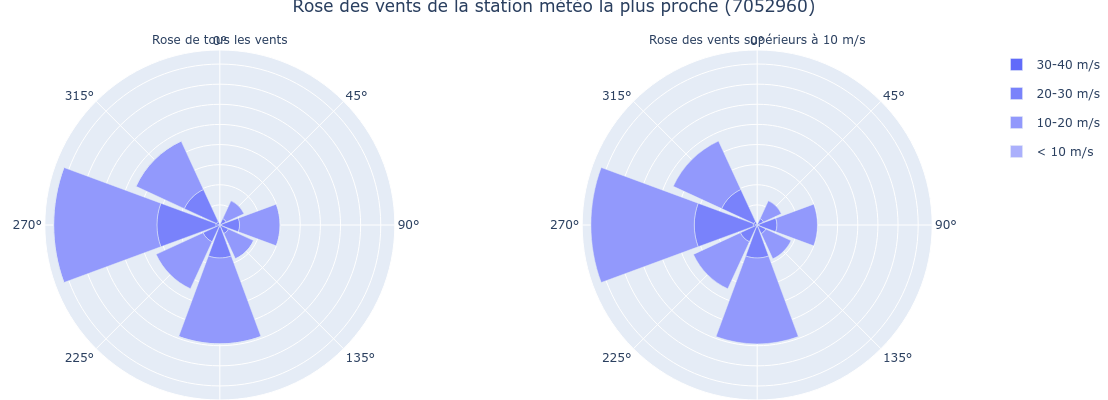

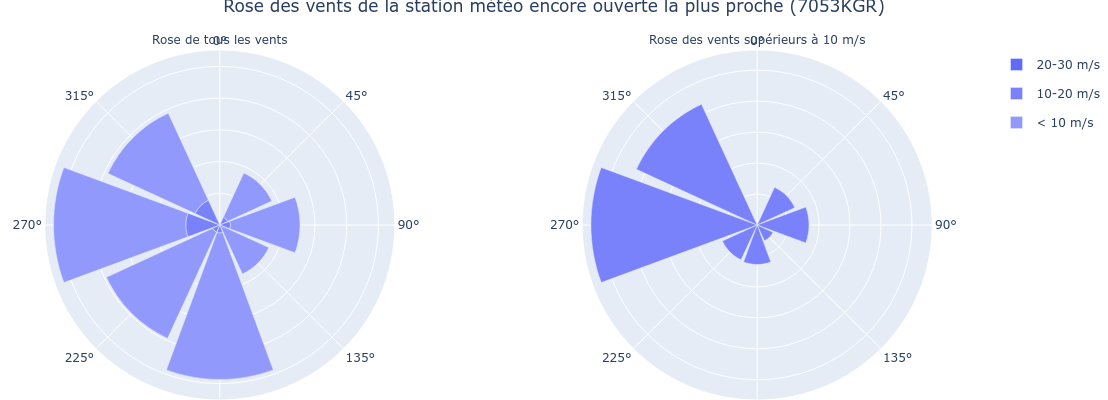

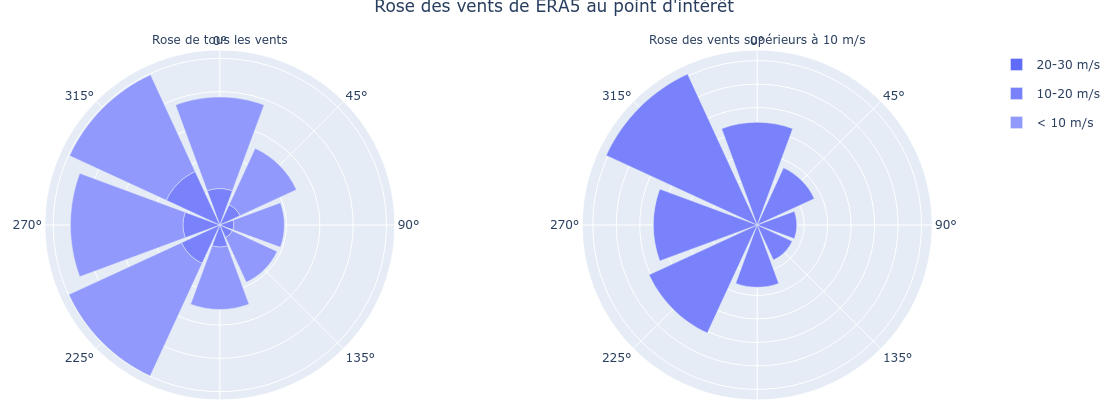

In [50]:
closest_fig = create_wind_rose(
    closest,
    title=f"Rose des vents de la station météo la plus proche ({closest[0,'station_id']})",
)
latest_fig = create_wind_rose(
    latest,
    title=f"Rose des vents de la station météo encore ouverte la plus proche ({latest[0,'station_id']})",
)
era5_fig = create_wind_rose(
    hourly_era5, title="Rose des vents de ERA5 au point d'intérêt"
)
closest_fig.write_image(figures_dir / "closest_rose_des_vents.svg")
latest_fig.write_image(figures_dir / "latest_rose_des_vents.svg")
era5_fig.write_image(figures_dir / "era5_rose_des_vents.svg")
closest_fig.show()
latest_fig.show()
era5_fig.show()

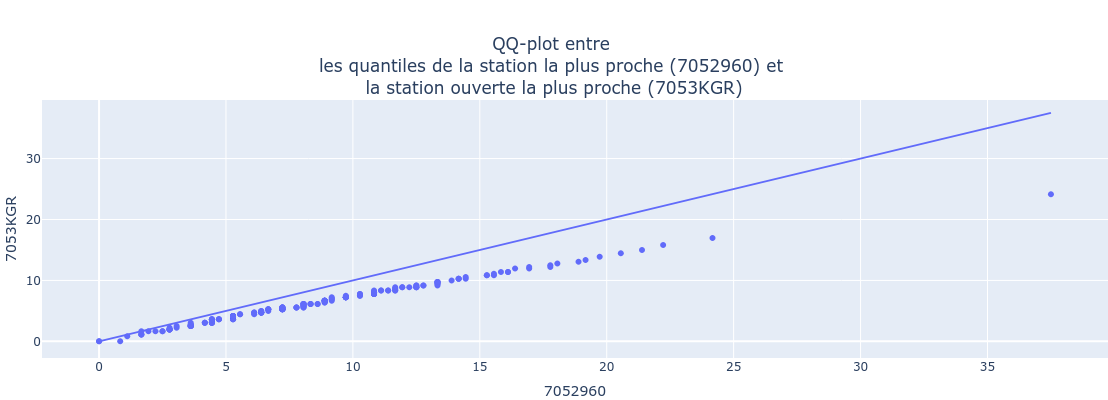

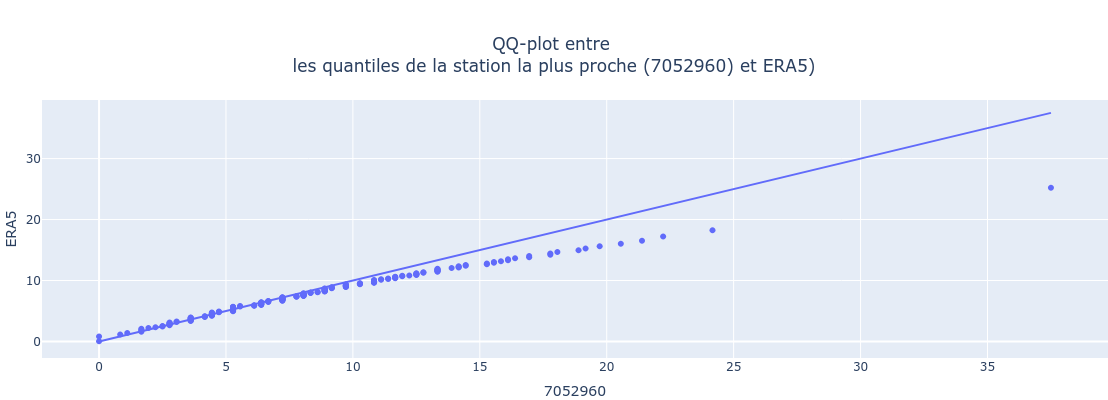

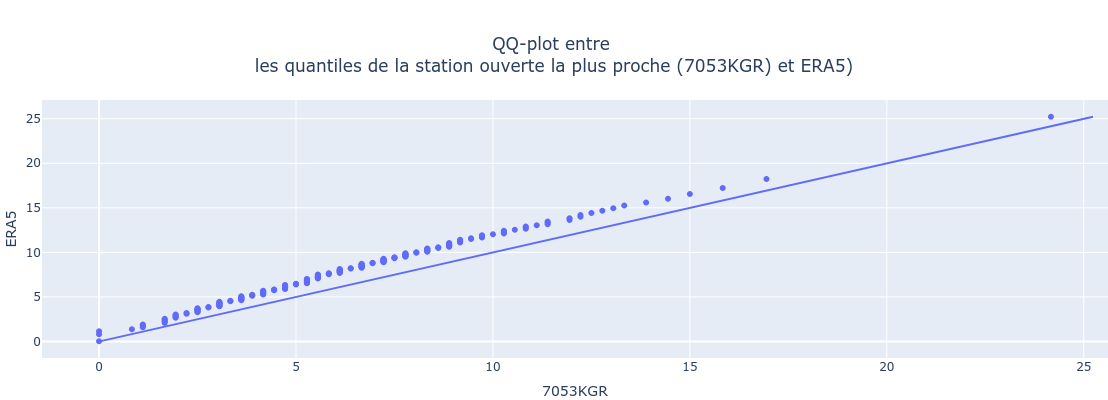

In [51]:
closest_latest_fig = create_qq_plot(
    closest["wind_speed"].alias(closest[0, "station_id"]),
    latest["wind_speed"].alias(latest[0, "station_id"]),
    title=f"QQ-plot entre <br>les quantiles de la station la plus proche ({closest[0,'station_id']}) et <br>la station ouverte la plus proche ({latest[0, 'station_id']})",
)
closest_era5_fig = create_qq_plot(
    closest["wind_speed"].alias(closest[0, "station_id"]),
    hourly_era5["wind_speed"].alias("ERA5"),
    title=f"QQ-plot entre <br>les quantiles de la station la plus proche ({closest[0,'station_id']}) et ERA5)",
)
latest_era5_fig = create_qq_plot(
    latest["wind_speed"].alias(latest[0, "station_id"]),
    hourly_era5["wind_speed"].alias("ERA5"),
    title=f"QQ-plot entre <br>les quantiles de la station ouverte la plus proche ({latest[0,'station_id']}) et ERA5)",
)
closest_latest_fig.write_image(figures_dir / "closest_latest_qq.svg")
closest_era5_fig.write_image(figures_dir / "closest_era5_qq.svg")
latest_era5_fig.write_image(figures_dir / "latest_era5_qq.svg")
closest_latest_fig.show()
closest_era5_fig.show()
latest_era5_fig.show()

## Couvert de glace

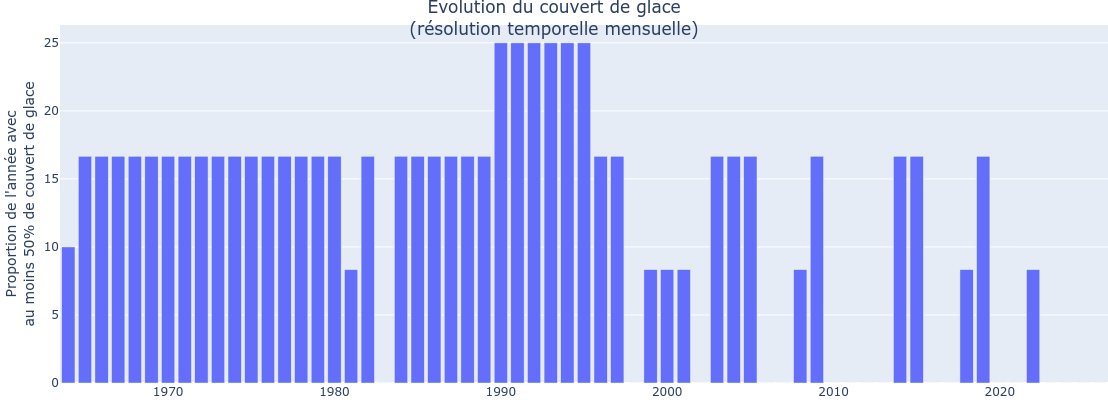

In [169]:
fig = create_ice_cover_plot(monthly_era5)
fig.write_image(figures_dir / "ice_cover.svg")
fig.show()

## Détermination des périodes de retour de tempêtes

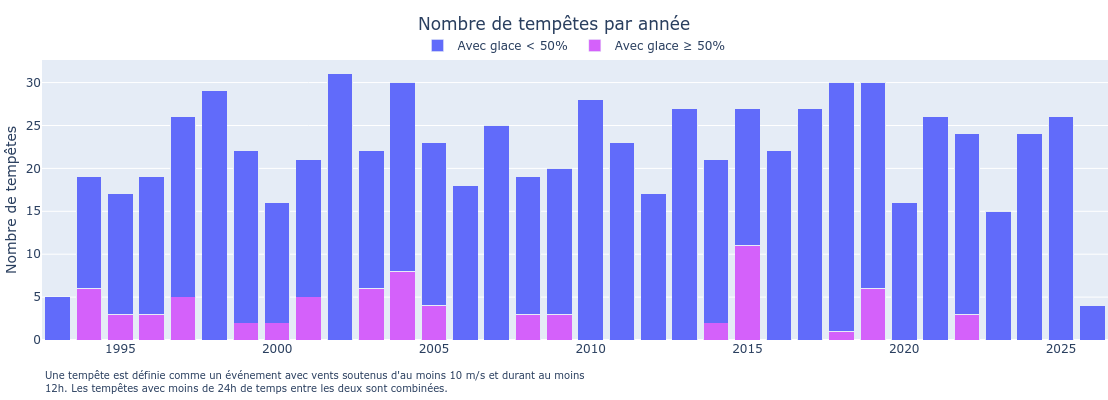

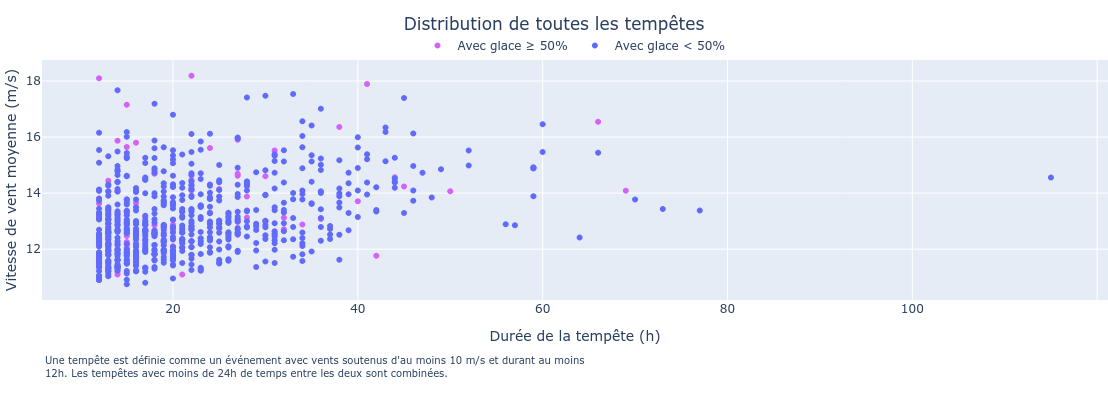

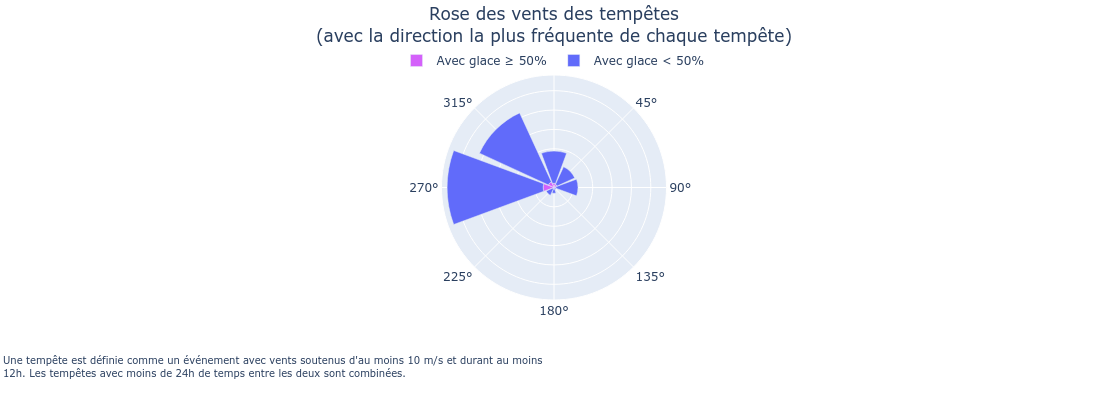

In [6]:
n_fig = create_storm_years_fig(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
intensity_fig = create_storm_intensity_fig(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
wind_rose_fig = create_storm_wind_rose(
    storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
n_fig.write_image(figures_dir / "storm_n.svg")
intensity_fig.write_image(figures_dir / "storm_intensity.svg")
wind_rose_fig.write_image(figures_dir / "storm_wind_rose.svg")
n_fig.show()
intensity_fig.show()
wind_rose_fig.show()

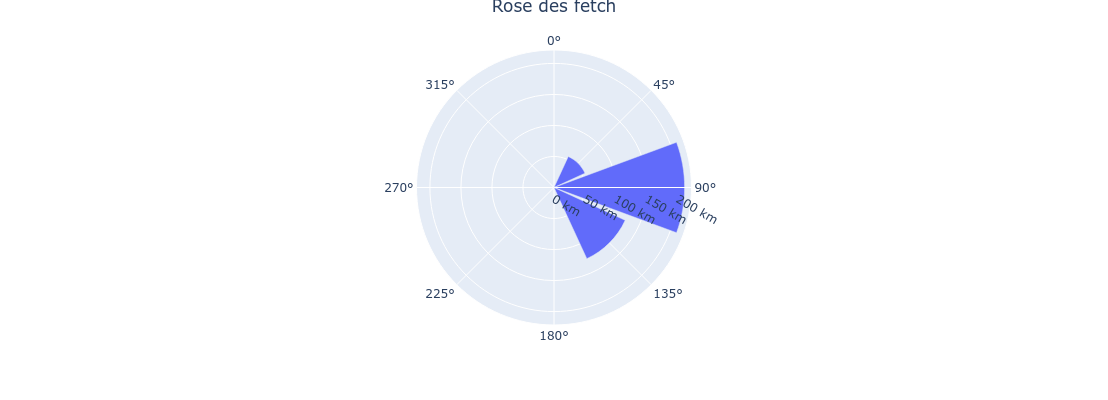

In [7]:
fetch_fig = create_fetch_wind_rose(fetch)
fetch_fig.write_image(figures_dir / "fetch.svg")
fetch_fig.show()

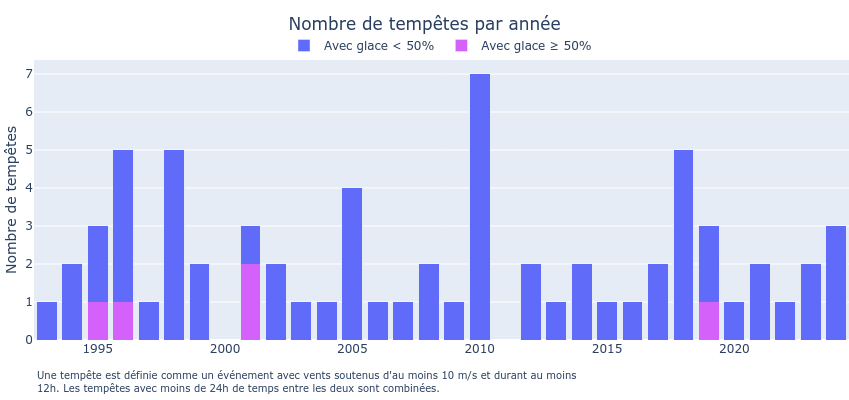

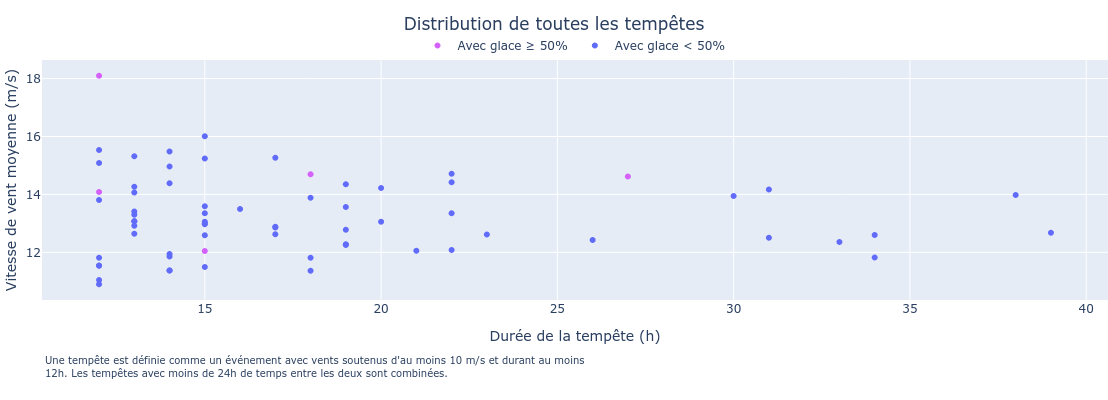

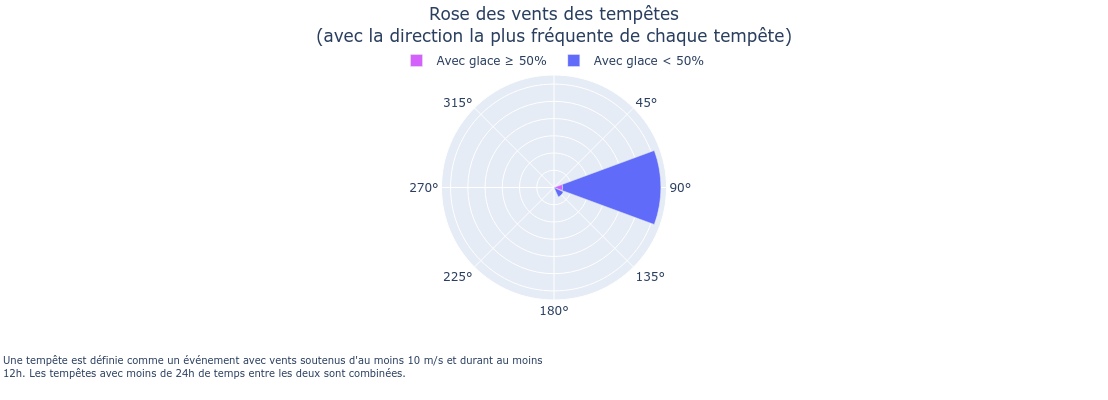

In [24]:
n_fig = create_storm_years_fig(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
intensity_fig = create_storm_intensity_fig(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
wind_rose_fig = create_storm_wind_rose(
    east_storms,
    wind_threshold=wind_threshold,
    duration_threshold=duration_threshold,
)
n_fig.write_image(figures_dir / "east_storm_n.svg")
intensity_fig.write_image(figures_dir / "east_storm_intensity.svg")
wind_rose_fig.write_image(figures_dir / "east_storm_wind_rose.svg")
n_fig.show()
intensity_fig.show()
wind_rose_fig.show()

In [5]:
wind_speed_fits = sorted(
    fit_storms(east_storms, "wind_speed_mean"), key=lambda x: x[2]
)
speed_fit_results = pl.DataFrame(
    [
        {
            "distribution": name,
            "qq_rmse": rmse,
            "qq_rmse_top_25": rmse_top_25,
        }
        for name, rmse, rmse_top_25, _ in wind_speed_fits
    ]
).sort("qq_rmse_top_25")
speed_fit_results.head(10)

distribution,qq_rmse,qq_rmse_top_25
str,f64,f64
"""GEV - 3 maximum annuels""",0.48774,0.161844
"""GEV - 4 maximum annuels""",0.605321,0.165275
"""Lognormale""",0.743705,0.181079
"""Weibull- 4 maximum annuels""",0.608323,0.20597
"""Weibull- 3 maximum annuels""",0.48737,0.210551
"""Weibull- 2 maximum annuels""",0.369675,0.238183
"""GEV - 2 maximum annuels""",0.365403,0.270122
"""GPD - POT(30%)""",0.55935,0.34439
"""GPD - POT(20%)""",0.515344,0.346784


In [6]:
duration_fits = sorted(fit_storms(east_storms, "duration"), key=lambda x: x[2])
duration_fit_results = pl.DataFrame(
    [
        {
            "distribution": name,
            "qq_rmse": rmse,
            "qq_rmse_top_25": rmse_top_25,
        }
        for name, rmse, rmse_top_25, _ in duration_fits
    ]
).sort("qq_rmse_top_25")
duration_fit_results.head(10)

distribution,qq_rmse,qq_rmse_top_25
str,f64,f64
"""GPD - POT(40%)""",4.836953,0.57603
"""GPD - POT(50%)""",5.792587,0.57603
"""GPD - POT(60%)""",7.802397,0.957928
"""GPD - POT(30%)""",2.26746,1.999292
"""GPD - POT(20%)""",1.532622,2.649064
"""GPD - POT(70%)""",15.193413,2.876911
"""Gumbel - maximum annuel""",1.528212,3.050094
"""Exponentielle - POT(20%)""",1.611014,3.211648
"""GPD - POT(80%)""",17.989517,3.344313


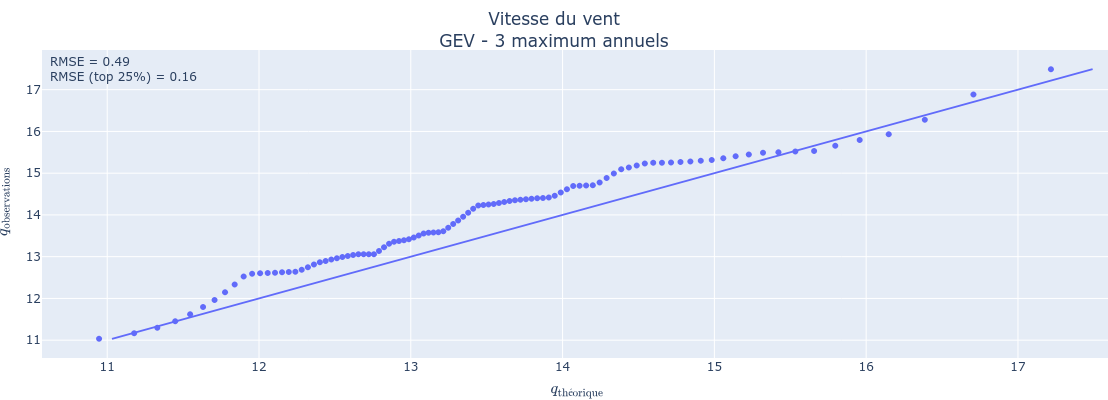

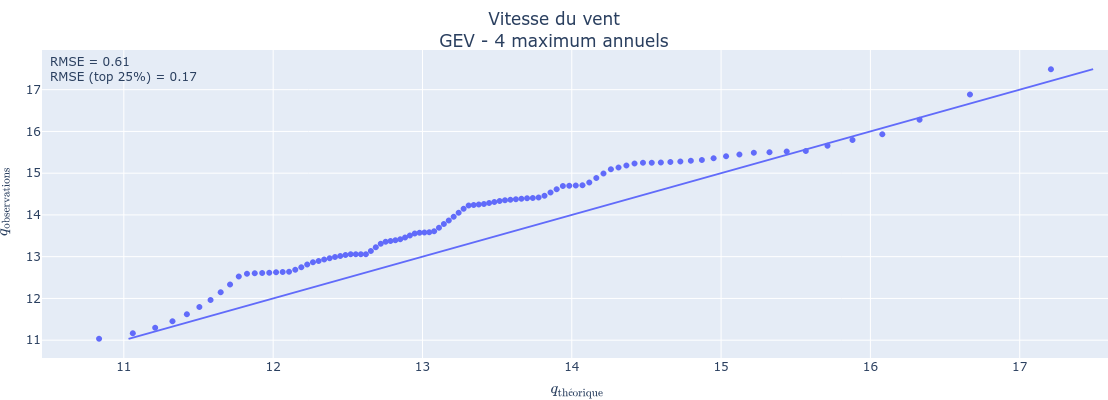

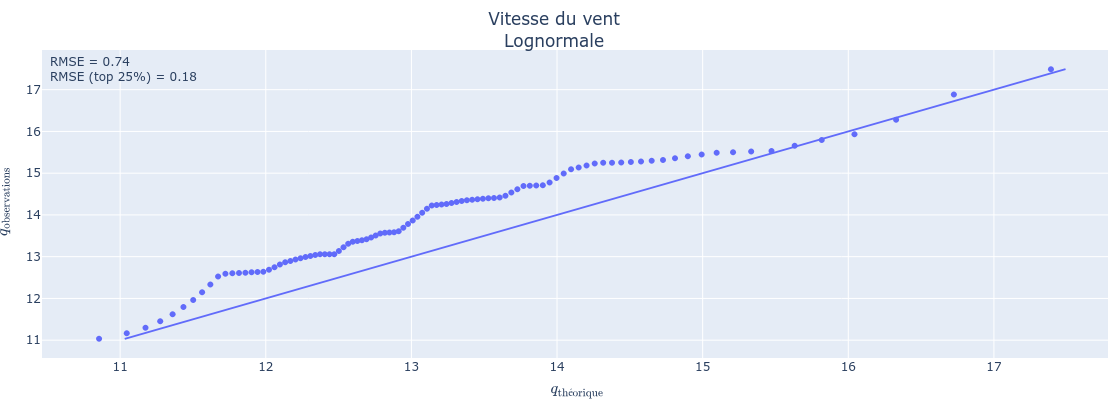

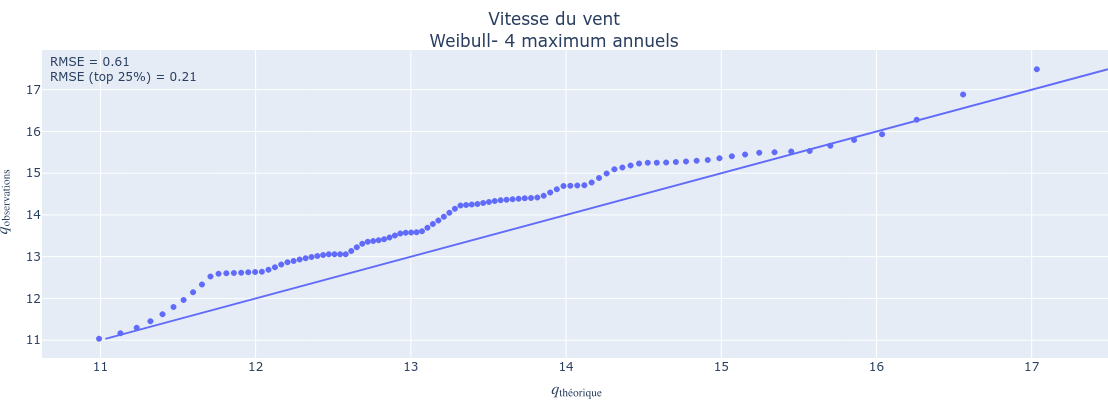

In [44]:
for i, fit in enumerate(wind_speed_fits[:4]):
    fig = create_storms_qq_plot(
        east_storms, "wind_speed_mean", "Vitesse du vent", fit
    )
    fig.write_image(figures_dir / f"speed_fit_{i+1}.svg")
    fig.show()

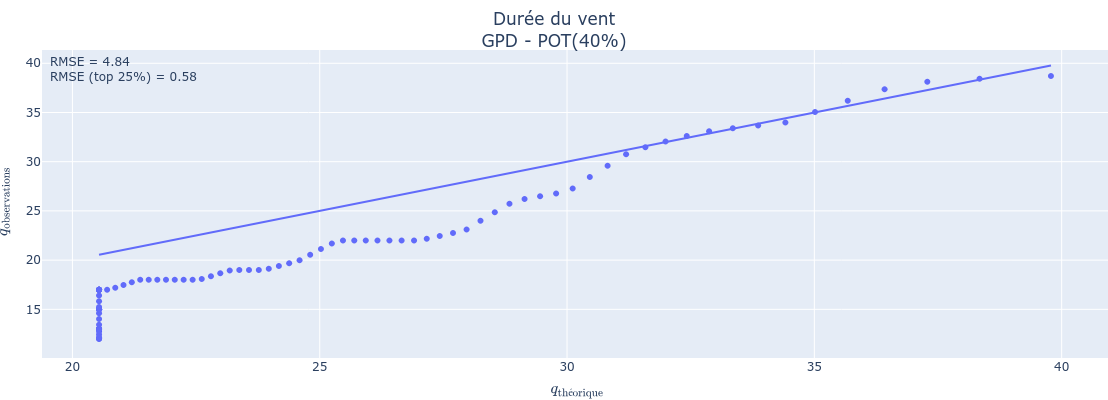

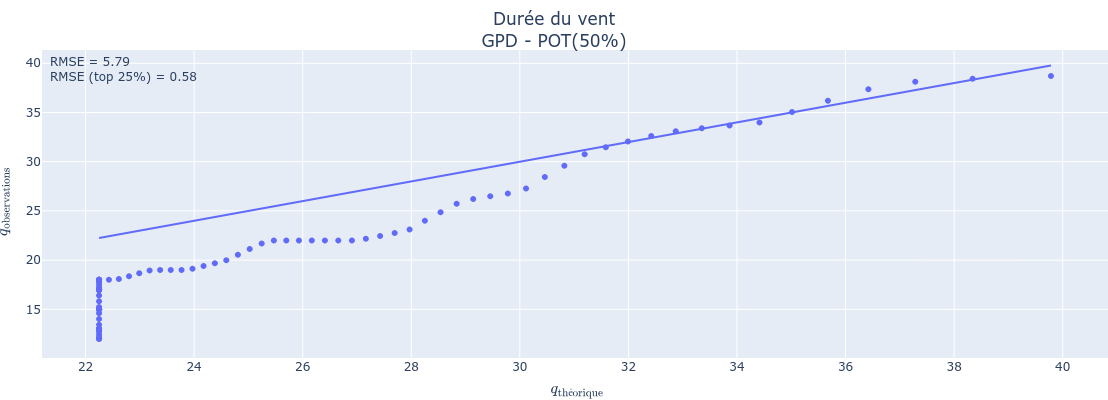

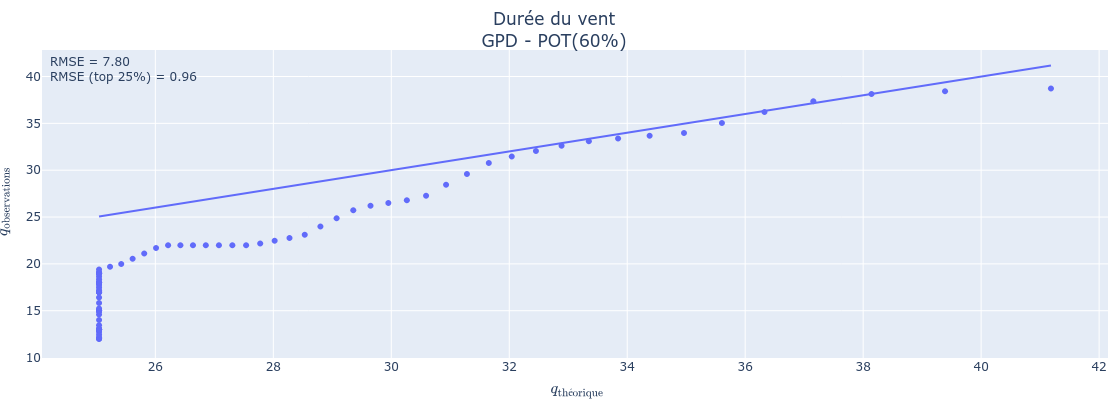

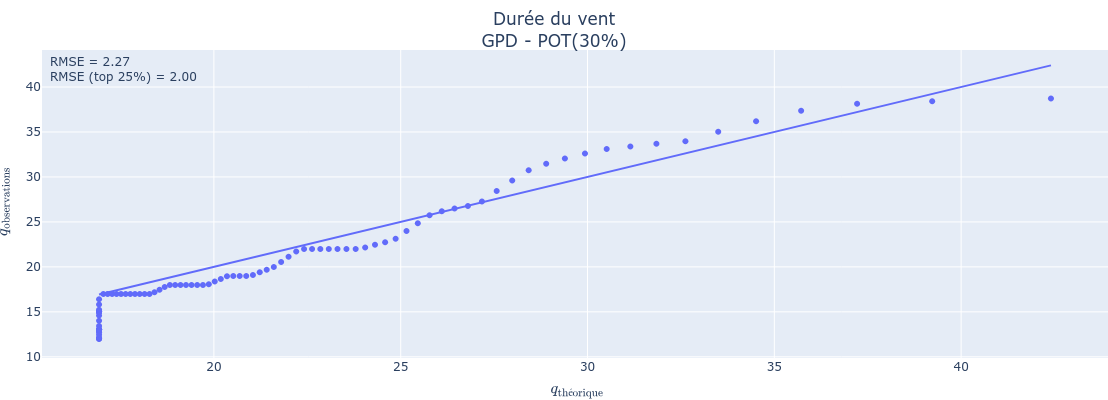

In [45]:
for i, fit in enumerate(duration_fits[:4]):
    fig = create_storms_qq_plot(east_storms, "duration", "Durée du vent", fit)
    fig.write_image(figures_dir / f"duration_fit_{i+1}.svg")
    fig.show()

In [9]:
return_periods = calculate_storm_return_periods(
    wind_speed_fits[0][3], duration_fits[0][3]
)
write_storm_return_periods(return_periods)
return_periods

period,wind_speed,duration
i64,f64,f64
50,16.706694,38.340669
100,17.217348,39.783561


## Ajustement des températures air-mer

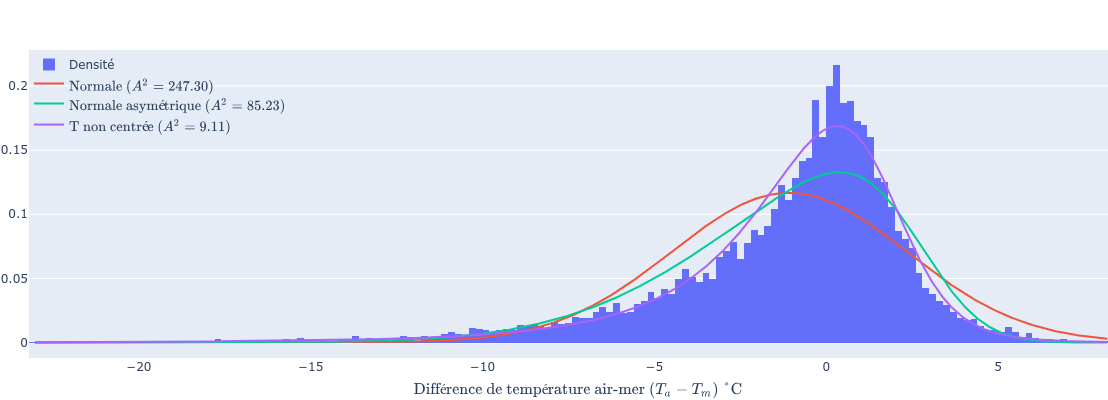

In [21]:
fig, diff_get_quantiles = create_land_sea_diff_fig(hourly_era5)
fig.write_image(figures_dir / "air-sea_diff.svg")
fig

In [22]:
diff_return_periods = pl.DataFrame(
    {
        "period": [50, 100],
        "diff": [diff_get_quantiles(1 / 50), diff_get_quantiles(1 / 100)],
        "R_T": [1.18, 1.2]
    }
)
write_diff_return_periods(diff_return_periods)
diff_return_periods

period,diff
i64,f64
50,-11.271675
100,-14.76868
